# Text as Data: TF-IDF and Document Similarity on SEC Filings

**Advanced Machine Learning for Finance — Lesson 1 Lab**  
University of Bologna, April–May 2026

---

## Objectives

This notebook applies the concepts from Lesson 1 to **real financial text**
drawn from the SEC EDGAR database:

1. **Corpus construction** — fetch 10-K annual filings from EDGAR for companies
   across different sectors.
2. **Preprocessing** — compare classical tokenization with subword (BPE)
   tokenization; examine the effect of stop-word removal, stemming, and
   lemmatization on the document-term matrix.
3. **TF-IDF representation** — build the sparse vector representation using
   scikit-learn and inspect which terms carry the most weight for each company.
4. **Document similarity** — compute and visualize cosine similarity; compare
   it with Euclidean distance to see why direction matters more than magnitude.
5. **Critical analysis** — identify where TF-IDF similarity matches human
   intuition (same-sector companies cluster together) and where it fails
   (semantic similarity without lexical overlap).

> **Data source:** All text is retrieved from the SEC EDGAR system
> ([https://www.sec.gov/edgar](https://www.sec.gov/edgar)), which is freely
> accessible for academic and research purposes.


## SEC EDGAR system

The U.S. Securities and Exchange Commission (SEC) maintains EDGAR, the Electronic Data Gathering, Analysis, and Retrieval system, which serves as the main public repository for corporate regulatory filings in the United States. Through EDGAR, researchers, investors, and analysts can access annual reports such as Form 10-K, quarterly reports such as Form 10-Q, and many other disclosures that describe a company’s business model, financial condition, risk exposures, and governance structure. In practice, these filings are an extremely valuable source of real-world financial text because they combine formal reporting requirements with rich narrative sections written by firms themselves.

In this notebook, we use the Python library EdgarTools to interact with EDGAR programmatically. Rather than manually browsing company filings on the SEC website, EdgarTools allows us to retrieve filings in a structured way, work with filing objects, and extract specific sections of interest from reports such as the 10-K. This is especially useful in text mining applications, because it lets us focus on a well-defined narrative section—in our case, the Risk Factors section—before applying NLP methods such as tokenization, preprocessing, TF-IDF vectorization, and document similarity analysis. By combining SEC data with EdgarTools, we can move from raw regulatory documents to a clean and reproducible analytical workflow.


---
## Setup and Dependencies


In [1]:
# Install dependencies (run once)
# !pip install requests beautifulsoup4 lxml scikit-learn matplotlib seaborn nltk tiktoken

import warnings
warnings.filterwarnings('ignore')

import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import to_rgba
from mpl_toolkits.axes_grid1 import make_axes_locatable

from collections import Counter

# NLP / ML
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.decomposition import TruncatedSVD

# Text processing
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

print("All imports successful.")


All imports successful.


---
## Building a Corpus from SEC EDGAR

We retrieve the most recent 10-K annual filing for a set of companies drawn
from different sectors.  The goal is to have a corpus where:

- **same-sector** companies discuss similar topics and should have high
  TF-IDF similarity;
- **cross-sector** companies discuss different topics and should have low
  similarity.

This gives us a natural ground truth to evaluate the representation.

### Company selection

| Ticker | Company | Sector |
|--------|---------|--------|
| JPM | JPMorgan Chase | Banking |
| GS | Goldman Sachs | Banking |
| BAC | Bank of America | Banking |
| AAPL | Apple | Technology |
| MSFT | Microsoft | Technology |
| GOOGL | Alphabet | Technology |
| XOM | ExxonMobil | Energy |
| CVX | Chevron | Energy |
| PFE | Pfizer | Healthcare |
| JNJ | Johnson & Johnson | Healthcare |
| KO | Coca-Cola | Consumer Staples |
| PG | Procter & Gamble | Consumer Staples |


In [2]:
import requests

# ── SEC EDGAR requires a User-Agent header ──────────────────────
HEADERS = {
    'User-Agent': 'giovanni.dellalunga@unibo.it',
    'Accept-Encoding': 'gzip, deflate',
}

# ── Company CIK numbers (Central Index Key) ─────────────────────
COMPANIES = {
    'JPM':   {'cik': 19617,   'sector': 'Banking'},
    'GS':    {'cik': 886982,  'sector': 'Banking'},
    'BAC':   {'cik': 70858,   'sector': 'Banking'},
    'AAPL':  {'cik': 320193,  'sector': 'Technology'},
    'MSFT':  {'cik': 789019,  'sector': 'Technology'},
    'GOOGL': {'cik': 1652044, 'sector': 'Technology'},
    'XOM':   {'cik': 34088,   'sector': 'Energy'},
    'CVX':   {'cik': 93410,   'sector': 'Energy'},
    'PFE':   {'cik': 78003,   'sector': 'Healthcare'},
    'JNJ':   {'cik': 200406,  'sector': 'Healthcare'},
    'KO':    {'cik': 21344,   'sector': 'Consumer'},
    'PG':    {'cik': 80424,   'sector': 'Consumer'},
}

print(f"Corpus will consist of {len(COMPANIES)} companies across "
      f"{len(set(c['sector'] for c in COMPANIES.values()))} sectors.")


Corpus will consist of 12 companies across 5 sectors.


### Fetching Filing Metadata from EDGAR

We use the EDGAR submissions API to find the most recent 10-K filing
for each company.


In [5]:
def get_latest_10k_url(cik):
    """
    Fetch the URL of the most recent 10-K filing for a given company CIK.

    Parameters
    ----------
    cik : int
        The company's Central Index Key assigned by the SEC.

    Returns
    -------
    tuple
        A pair `(filing_url, accession_number)`.
        If no 10-K filing is found, returns `(None, None)`.
    """

    # The SEC submissions endpoint requires the CIK to be zero-padded
    # to 10 digits. For example, CIK 19617 becomes "0000019617".
    url = f"https://data.sec.gov/submissions/CIK{cik:010d}.json"

    # Send an HTTP GET request to the SEC endpoint.
    # HEADERS must include a valid User-Agent, as required by the SEC.
    resp = requests.get(url, headers=HEADERS)

    # Raise an exception if the request failed, for example because of
    # a network error, invalid response, or HTTP error code.
    resp.raise_for_status()

    # Parse the JSON response into a Python dictionary.
    data = resp.json()

    # The most recent filings are stored under data['filings']['recent'].
    recent = data['filings']['recent']

    # Extract the parallel lists containing filing forms, accession numbers,
    # and primary document names.
    forms = recent['form']
    accessions = recent['accessionNumber']
    primary_docs = recent['primaryDocument']

    # Iterate over all recent filings in chronological order as returned
    # by the SEC, looking for the first filing whose form type is "10-K".
    for i, form in enumerate(forms):

        # Select the most recent annual report.
        if form == '10-K':

            # Accession numbers in the JSON contain dashes, for example:
            # "0000019617-25-000123".
            # In the SEC archive URL, the accession number must be used
            # without dashes.
            acc = accessions[i].replace('-', '')

            # The primary document is the actual filing document, usually
            # an HTML file.
            doc = primary_docs[i]

            # Construct the direct URL to the filing document in the SEC
            # EDGAR archive.
            filing_url = (
                f"https://www.sec.gov/Archives/edgar/data/"
                f"{cik}/{acc}/{doc}"
            )

            # Return both the direct filing URL and the original accession
            # number with dashes, which is useful for identification.
            return filing_url, accessions[i]

    # If no 10-K form is found among recent filings, return empty values.
    return None, None


# ── Retrieve filing URLs ────────────────────────────────────────

# Dictionary that will store the latest 10-K URL for each company ticker.
# Structure: ticker -> filing URL
filing_urls = {}

# Loop over the selected companies defined in the COMPANIES dictionary.
# Each entry contains the company CIK and its sector classification.
for ticker, info in COMPANIES.items():

    # Retrieve the latest 10-K filing URL and accession number
    # for the current company.
    url, accession = get_latest_10k_url(info['cik'])

    # Store the URL in the dictionary, using the ticker as key.
    # If no filing is found, url will be None.
    filing_urls[ticker] = url

    # Prepare a simple visual status indicator for the notebook output.
    status = "✓" if url else "✗ not found"

    # Print ticker, sector, and retrieval status in aligned columns.
    print(f"  {ticker:6s} ({info['sector']:12s})  {status}")

    # Pause briefly to respect SEC rate limits.
    # The SEC allows no more than 10 requests per second.
    time.sleep(0.12)

# Print a final summary showing how many filings were successfully found.
print(
    f"\nFound {sum(1 for v in filing_urls.values() if v)} / "
    f"{len(filing_urls)} filings."
)

  JPM    (Banking     )  ✓
  GS     (Banking     )  ✓
  BAC    (Banking     )  ✓
  AAPL   (Technology  )  ✓
  MSFT   (Technology  )  ✓
  GOOGL  (Technology  )  ✓
  XOM    (Energy      )  ✓
  CVX    (Energy      )  ✓
  PFE    (Healthcare  )  ✓
  JNJ    (Healthcare  )  ✓
  KO     (Consumer    )  ✓
  PG     (Consumer    )  ✓

Found 12 / 12 filings.


### Downloading and Extracting Text



In [6]:
from edgar import set_identity

set_identity("giovanni.dellalunga@unibo.it")

In [7]:
import re
import time
from edgar import Company

def extract_text_from_filing(cik, max_chars=None):
    """
    Extract the full Risk Factors section (Item 1A) from the latest 10-K
    of the company identified by CIK, using EdgarTools.

    Parameters
    ----------
    cik : int
        Company CIK number.
    max_chars : int or None, default None
        Optional truncation of the extracted text.
        Use None to keep the full Risk Factors section.

    Returns
    -------
    str or None
        Cleaned Risk Factors text, or None if extraction fails.
    """
    try:
        company = Company(str(cik))
        filing = company.get_filings(form="10-K").latest()
    except Exception as e:
        print(f"    ⚠ Unable to retrieve 10-K: {e}")
        return None

    if filing is None:
        print("    ⚠ No 10-K found")
        return None

    try:
        tenk = filing.obj()
    except Exception as e:
        print(f"    ⚠ Unable to parse filing object: {e}")
        return None

    if tenk is None:
        print("    ⚠ filing.obj() returned None")
        return None

    text = None

    # Preferred access pattern documented by EdgarTools
    try:
        risk_factors = getattr(tenk, "risk_factors", None)
        if risk_factors is not None:
            if isinstance(risk_factors, str):
                text = risk_factors
            else:
                text = getattr(risk_factors, "text", None)
                if text is None:
                    text = str(risk_factors)
    except Exception:
        pass

    # Fallback: try Item 1A directly
    if not text:
        try:
            item_1a = tenk["Item 1A"]
            if isinstance(item_1a, str):
                text = item_1a
            else:
                text = getattr(item_1a, "text", None)
                if text is None:
                    text = str(item_1a)
        except Exception:
            pass

    if not text:
        print("    ⚠ Risk Factors section not found")
        return None

    # Basic cleanup
    text = re.sub(r"\s+", " ", text).strip()

    if max_chars is not None and len(text) > max_chars:
        text = text[:max_chars]

    return text


# ── Build corpus from Risk Factors sections ─────────────────────
corpus = {}

for ticker, info in COMPANIES.items():
    print(f"  Downloading {ticker} Risk Factors...", end=' ')
    text = extract_text_from_filing(info['cik'])

    if text and len(text) > 1000:
        corpus[ticker] = text
        print(f"{len(text):,} chars")
    else:
        print("⚠ too short or failed")

    time.sleep(0.15)

print(f"\n{'='*50}")
print(f"Corpus ready: {len(corpus)} documents")

for ticker, text in corpus.items():
    sector = COMPANIES[ticker]['sector']
    print(f"  {ticker:6s} ({sector:12s}): {len(text):>7,} chars, "
          f"{len(text.split()):>5,} tokens (approx)")


Corpus ready: 12 documents
  JPM    (Banking     ): 112,059 chars, 15,493 tokens (approx)
  GS     (Banking     ): 141,706 chars, 21,272 tokens (approx)
  BAC    (Banking     ): 116,845 chars, 16,618 tokens (approx)
  AAPL   (Technology  ):  68,042 chars, 9,782 tokens (approx)
  MSFT   (Technology  ):  68,893 chars, 10,076 tokens (approx)
  GOOGL  (Technology  ):  84,929 chars, 12,583 tokens (approx)
  XOM    (Energy      ):  35,526 chars, 5,085 tokens (approx)
  CVX    (Energy      ):  34,479 chars, 4,937 tokens (approx)
  PFE    (Healthcare  ):  87,327 chars, 12,697 tokens (approx)
  JNJ    (Healthcare  ):  43,306 chars, 6,272 tokens (approx)
  KO     (Consumer    ):  92,209 chars, 13,488 tokens (approx)
  PG     (Consumer    ):  38,094 chars, 5,479 tokens (approx)


## Preprocessing

### Classical vs. BPE Tokenization

We compare how classical word-level tokenization and BPE (as used by GPT-4)
segment typical financial text.


In [8]:
# ── Pick a sample sentence from the corpus ──────────────────────
sample_ticker = list(corpus.keys())[0]
print(sample_ticker)

JPM


In [9]:
sentences = corpus[sample_ticker].split('.')
print(len(sentences))

448


In [10]:
# Find a reasonably interesting sentence
sample_sentence = None
for s in sentences:
    words = s.strip().split()
    
    if (
        30 < len(words) < 50
        and any(w[0].isupper() for w in words[1:] if w)
        and any(w.isupper() and len(w) >= 4 for w in words)
        ):
        sample_sentence = s.strip() + '.'
        break
    '''
    if (
            30 < len(words) < 50
            and any(w[0].isupper() for w in words[1:] if w)
            and any('EBITDA' in re.sub(r'^\W+|\W+$', '', w).upper() for w in words)
        ):        
        sample_sentence = s.strip() + '.'
        break
    '''
        
if sample_sentence is None:
    sample_sentence = '. '.join(sentences[3:5]).strip()
    print("Target word not found!")

print(f"Sample sentence from {sample_ticker} 10-K:\n")
print(f'  "{sample_sentence[:500]}..."' if len(sample_sentence)>500
      else f'  "{sample_sentence}"')


Sample sentence from JPM 10-K:

  "JPMorganChase must periodically submit a detailed resolution plan to the Federal Reserve and the FDIC for its rapid and orderly resolution in bankruptcy, without extraordinary government support, in the event of material financial distress or failure."


In [13]:
# ── Classical tokenization ───────────────────────────────────────
classical_tokens = word_tokenize(sample_sentence.lower())
print(f"Classical tokenization ({len(classical_tokens)} tokens):")
print(f"  {classical_tokens[:25]}")

# ── BPE tokenization (GPT-4 tokenizer) ─────────────────────────
try:
    import tiktoken
    enc = tiktoken.encoding_for_model("gpt-4")
    bpe_token_ids = enc.encode(sample_sentence)
    bpe_tokens = [enc.decode([t]) for t in bpe_token_ids]
    print(f"\nBPE tokenization ({len(bpe_tokens)} tokens):")
    print(f"  {bpe_tokens[:25]}")

    print(f"\n── Comparison ──────────────────────────────")
    print(f"  Classical: {len(classical_tokens):>4} tokens")
    print(f"  BPE:       {len(bpe_tokens):>4} tokens")
except ImportError:
    print("\n⚠ tiktoken not installed. Install with: pip install tiktoken")


Classical tokenization (39 tokens):
  ['jpmorganchase', 'must', 'periodically', 'submit', 'a', 'detailed', 'resolution', 'plan', 'to', 'the', 'federal', 'reserve', 'and', 'the', 'fdic', 'for', 'its', 'rapid', 'and', 'orderly', 'resolution', 'in', 'bankruptcy', ',', 'without']

BPE tokenization (44 tokens):
  ['J', 'PM', 'organ', 'Ch', 'ase', ' must', ' periodically', ' submit', ' a', ' detailed', ' resolution', ' plan', ' to', ' the', ' Federal', ' Reserve', ' and', ' the', ' FD', 'IC', ' for', ' its', ' rapid', ' and', ' orderly']

── Comparison ──────────────────────────────
  Classical:   39 tokens
  BPE:         44 tokens


#### Observation

BPE produces a different number of tokens and handles financial terms
(tickers, acronyms, numbers) in ways that may surprise:

- Numbers like `$12,345.67` are split into arbitrary fragments
- Acronyms like `EBITDA` become `EB|IT|DA`
- This is one reason why LLMs struggle with arithmetic and precise entity matching


### The Effect of Preprocessing Choices


Before computing TF-IDF vectors, we construct several alternative versions of the corpus in order to examine how preprocessing choices affect the final representation of the documents. In particular, we move from the `raw` text to three progressively more processed variants: `no_stopwords`, `stemmed`, and `lemmatized`. Each version reflects a different balance between preserving the original wording of the Risk Factors sections and reducing linguistic variation that may not be analytically useful. Rather than treating preprocessing as a purely mechanical cleaning step, this notebook uses it as an opportunity to show that document representation is shaped by a sequence of modeling decisions.

These choices matter because the next stages of the analysis depend directly on the vocabulary produced here. The `raw` corpus preserves the text in a form that remains closer to the original filing language, but it also includes more redundancy and frequent function words. The `no_stopwords` version removes many common words and therefore shifts attention toward more content-bearing terms. The `stemmed` corpus further reduces words to simplified roots, which may help consolidate related forms but can make the text less interpretable. Finally, the `lemmatized` version aims to normalize words in a linguistically cleaner way, often preserving readability better than stemming. In the sections that follow, these alternative representations provide the basis for TF-IDF weighting, for the identification of distinctive terms, and for the comparison of document similarity across firms and sectors.

In [15]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


def preprocess(text, remove_stops=False, do_stem=False, do_lemma=False):
    '''Tokenize and optionally normalize text.'''
    # Lowercase and tokenize
    tokens = word_tokenize(text.lower())
    # Keep only alphabetic tokens
    tokens = [t for t in tokens if t.isalpha() and len(t) > 2]
    if remove_stops:
        tokens = [t for t in tokens if t not in stop_words]
    if do_stem:
        tokens = [stemmer.stem(t) for t in tokens]
    elif do_lemma:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


# ── Build four versions of the corpus ───────────────────────────
tickers = sorted(corpus.keys())
raw_docs = [corpus[t] for t in tickers]

versions = {
    'raw':          [preprocess(d) for d in raw_docs],
    'no_stopwords': [preprocess(d, remove_stops=True) for d in raw_docs],
    'stemmed':      [preprocess(d, remove_stops=True, do_stem=True)
                     for d in raw_docs],
    'lemmatized':   [preprocess(d, remove_stops=True, do_lemma=True)
                     for d in raw_docs],
}

# ── Compare vocabulary sizes ────────────────────────────────────
print(f"{'Version':<16} {'Vocab size':>12} {'Avg tokens/doc':>16}")
print("─" * 48)
for name, docs in versions.items():
    all_tokens = ' '.join(docs).split()
    vocab = set(all_tokens)
    avg_len = np.mean([len(d.split()) for d in docs])
    print(f"{name:<16} {len(vocab):>12,} {avg_len:>16,.0f}")


Version            Vocab size   Avg tokens/doc
────────────────────────────────────────────────
raw                     5,462            8,893
no_stopwords            5,377            6,560
stemmed                 3,059            6,560
lemmatized              4,615            6,560


#### Key takeaway

Each preprocessing step **reduces** the vocabulary size — this is a form of
information compression.  Stemming seems to be the most aggressive single step;

The question is always: **does the removed information matter for the task?**
For document-level similarity, removing stop words typically helps.  But for
sentiment analysis, removing "not" can invert the meaning of a sentence.


---
## TF-IDF Representation

We build the TF-IDF matrix using the **lemmatized, stop-word-free** version
of the corpus — the version that best balances vocabulary reduction with
semantic preservation.


In [16]:
# ── Build TF-IDF matrix ──────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=5000,     # keep top 5000 terms
    min_df=2,              # term must appear in at least 2 docs
    max_df=0.95,           # ignore terms in >95% of docs
    sublinear_tf=False,    # raw TF (no log), to match lecture
    norm='l2',             # L2 normalization (standard)
)

docs_for_tfidf = versions['lemmatized']
tfidf_matrix = tfidf.fit_transform(docs_for_tfidf)
feature_names = tfidf.get_feature_names_out()

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"  {tfidf_matrix.shape[0]} documents × {tfidf_matrix.shape[1]} terms")
print(f"  Density: {tfidf_matrix.nnz / np.prod(tfidf_matrix.shape):.2%}")
print(f"  (i.e., {100 - tfidf_matrix.nnz / np.prod(tfidf_matrix.shape)*100:.1f}%"
      f" of entries are zero — this is a sparse representation)")


TF-IDF matrix shape: (12, 2584)
  12 documents × 2584 terms
  Density: 39.48%
  (i.e., 60.5% of entries are zero — this is a sparse representation)


### Most Distinctive Terms per Company

For each document (company), we extract the terms with the highest TF-IDF
weight.  These are terms that are **frequent in that document** but
**relatively rare across the corpus** — exactly the terms that make the
document distinctive.


In [18]:
def top_tfidf_terms(matrix, feature_names, doc_index, n=10):
    '''Return the top-n TF-IDF terms for a given document.'''
    row = matrix[doc_index].toarray().flatten()
    top_idx = row.argsort()[::-1][:n]
    return [(feature_names[i], round(row[i], 3)) for i in top_idx]


# ── Display top terms per company ───────────────────────────────
print(f"{'Ticker':<8} {'Sector':<14} Top 8 TF-IDF terms")
print("─" * 80)
for i, ticker in enumerate(tickers):
    sector = COMPANIES[ticker]['sector']
    terms = top_tfidf_terms(tfidf_matrix, feature_names, i, n=8)
    term_str = ', '.join(f"{t}" for t, w in terms)
    print(f"{ticker:<8} {sector:<14} {term_str}")


Ticker   Sector         Top 8 TF-IDF terms
────────────────────────────────────────────────────────────────────────────────
AAPL     Technology     stock, materially, component, customer, property, content, foreign, application
BAC      Banking        client, credit, bank, capital, value, federal, loan, counterparties
CVX      Energy         ghg, esg, ambition, gas, emission, oil, hydrocarbon, crude
GOOGL    Technology     user, content, advertiser, customer, google, director, protection, platform
GS       Banking        client, group, subsidiary, credit, transaction, institution, past, counterparties
JNJ      Healthcare     planned, manufacturing, patent, healthcare, patient, pharmaceutical, approval, property
JPM      Banking        client, customer, parent, credit, capital, counterparties, loan, estimation
KO       Consumer       packaging, ingredient, brand, agricultural, substance, plastic, concern, united
MSFT     Technology     customer, user, software, device, content, attack, 

#### Interpretation

Look at the results:
- Do **banking** companies share similar top terms (e.g., *loan*, *deposit*,
  *credit*, *interest*)?
- Do **technology** companies share different terms (e.g., *cloud*, *user*,
  *revenue*, *advertising*)?
- Are there terms that appear as "top" for companies in different sectors?
  What does that tell us about the specificity of TF-IDF?

> **This is the IDF mechanism at work**: terms like *revenue* or *operating*
> are common across all 10-K filings and receive low IDF weight.  Terms like
> *drilling* or *pharmaceutical* are sector-specific and receive high IDF weight.


## Document Similarity

Now we compute how similar each pair of documents is, using both cosine
similarity and Euclidean distance.  We expect to see a clear difference
in their behavior.


### Cosine Similarity Matrix


In [19]:
# ── Compute cosine similarity ────────────────────────────────────
cos_sim = cosine_similarity(tfidf_matrix)
cos_df = pd.DataFrame(cos_sim, index=tickers, columns=tickers)

# ── Assign colors by sector ─────────────────────────────────────
sector_colors = {
    'Banking':    '#1f77b4',
    'Technology': '#2ca02c',
    'Energy':     '#d62728',
    'Healthcare': '#9467bd',
    'Consumer':   '#ff7f0e',
}

row_colors = [sector_colors[COMPANIES[t]['sector']] for t in tickers]

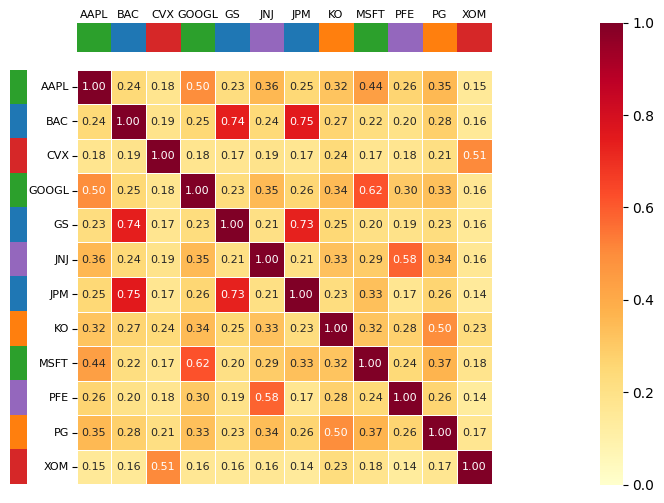

In [20]:
tickers = list(cos_df.index)
n = len(tickers)

# Colori RGBA
color_array = np.array([to_rgba(c) for c in row_colors])

fig, ax = plt.subplots(figsize=(10, 6))

# Heatmap principale
hm = sns.heatmap(
    cos_df,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    square=True,
    ax=ax,
    linewidths=0.5,
    linecolor="white",
    cbar=True
)

# Nessun titolo
ax.set_title("")

# Etichette asse principale
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
ax.set_xticklabels([])                 # togliamo quelle sotto
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', pad=2)

# Divider: crea assi agganciati alla heatmap
divider = make_axes_locatable(ax)

# Barra superiore: stessa larghezza della heatmap
ax_top = divider.append_axes("top", size="7%", pad=0.18)

# Barra sinistra: più distante per non sovrapporsi alle y-label
ax_left = divider.append_axes("left", size="4%", pad=0.5)

# ----- Barra superiore -----
top_img = color_array.reshape(1, n, 4)
ax_top.imshow(top_img, aspect="auto", origin="upper")

ax_top.set_xlim(-0.5, n - 0.5)
ax_top.set_xticks(np.arange(n))
ax_top.set_xticklabels(tickers, rotation=0, fontsize=8)
ax_top.xaxis.set_ticks_position("top")
ax_top.tick_params(axis="x", length=0, pad=2)
ax_top.set_yticks([])

for spine in ax_top.spines.values():
    spine.set_visible(False)

# ----- Barra sinistra -----
left_img = color_array.reshape(n, 1, 4)
ax_left.imshow(left_img, aspect="auto", origin="upper")

ax_left.set_ylim(n - 0.5, -0.5)   # allinea l'ordine con la heatmap
ax_left.set_xticks([])
ax_left.set_yticks([])

for spine in ax_left.spines.values():
    spine.set_visible(False)

plt.show()

### Do Companies Cluster by Sector?

Let us check numerically whether same-sector pairs have higher similarity
than cross-sector pairs.


Average cosine similarity:
  Within sector:  0.597  (n = 9 pairs)
  Across sectors: 0.237  (n = 57 pairs)
  Ratio:          2.51x


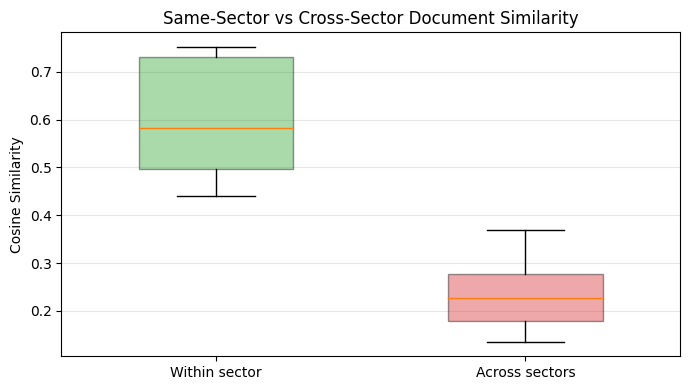

In [21]:
# ── Compute within-sector vs across-sector similarity ───────────
within_sector = []
across_sector = []

for i in range(len(tickers)):
    for j in range(i+1, len(tickers)):
        sim = cos_sim[i, j]
        if COMPANIES[tickers[i]]['sector'] == COMPANIES[tickers[j]]['sector']:
            within_sector.append(sim)
        else:
            across_sector.append(sim)

print(f"Average cosine similarity:")
print(f"  Within sector:  {np.mean(within_sector):.3f}  "
      f"(n = {len(within_sector)} pairs)")
print(f"  Across sectors: {np.mean(across_sector):.3f}  "
      f"(n = {len(across_sector)} pairs)")
print(f"  Ratio:          {np.mean(within_sector)/np.mean(across_sector):.2f}x")

# ── Boxplot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
data = [within_sector, across_sector]
bp = ax.boxplot(data, labels=['Within sector', 'Across sectors'],
                patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#2ca02c')
bp['boxes'][0].set_alpha(0.4)
bp['boxes'][1].set_facecolor('#d62728')
bp['boxes'][1].set_alpha(0.4)
ax.set_ylabel('Cosine Similarity')
ax.set_title('Same-Sector vs Cross-Sector Document Similarity')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Euclidean Distance vs Cosine Similarity

Recall from the lecture that Euclidean distance conflates **what** a document
is about (direction) with **how long** it is (magnitude).  Let us verify this
empirically.


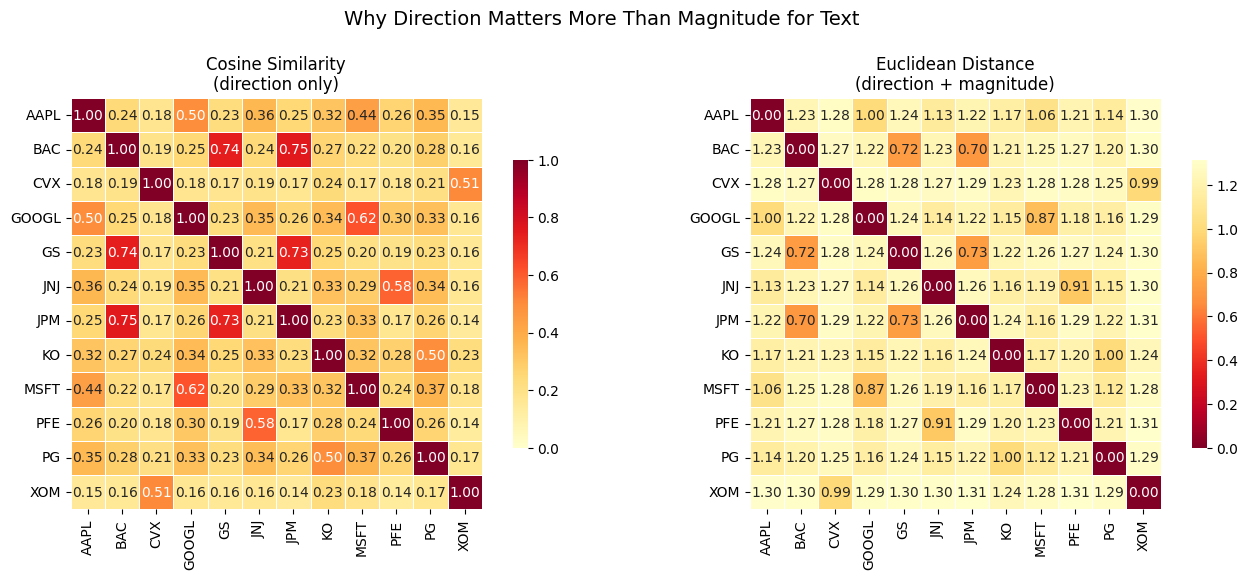

Rank correlation between cosine similarity and (-Euclidean): 0.996
(Should be high but not perfect — the two metrics do NOT always agree.)


In [22]:
# ── Compute Euclidean distances ──────────────────────────────────
euc_dist = euclidean_distances(tfidf_matrix)

# ── Compare the two metrics ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Cosine similarity
sns.heatmap(cos_df, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, square=True, ax=axes[0],
            linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.7})
axes[0].set_title('Cosine Similarity\n(direction only)', fontsize=12)

# Euclidean distance
euc_df = pd.DataFrame(euc_dist, index=tickers, columns=tickers)
sns.heatmap(euc_df, annot=True, fmt='.2f', cmap='YlOrRd_r',
            square=True, ax=axes[1],
            linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.7})
axes[1].set_title('Euclidean Distance\n(direction + magnitude)', fontsize=12)

plt.suptitle('Why Direction Matters More Than Magnitude for Text',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── Correlation between the two ─────────────────────────────────
upper_cos = cos_sim[np.triu_indices_from(cos_sim, k=1)]
upper_euc = euc_dist[np.triu_indices_from(euc_dist, k=1)]
corr = np.corrcoef(upper_cos, -upper_euc)[0, 1]
print(f"Rank correlation between cosine similarity and (-Euclidean): {corr:.3f}")
print("(Should be high but not perfect — the two metrics do NOT always agree.)")


### Visualizing the Document Space

We reduce the TF-IDF vectors to 2 dimensions using Truncated SVD (a form of
dimensionality reduction related to PCA) to visualize how documents cluster.


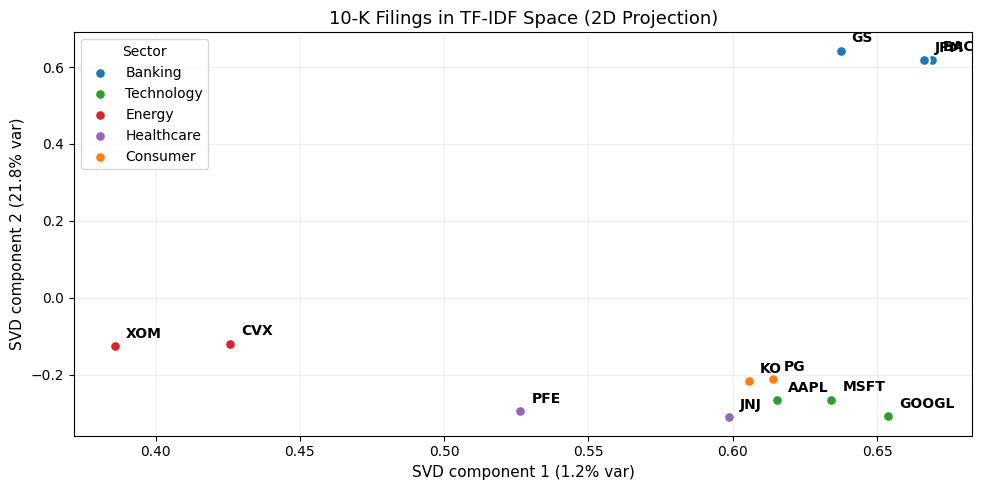

Total variance explained by 2 components: 23.0%


In [23]:
# ── 2D projection via Truncated SVD ─────────────────────────────
svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(tfidf_matrix)

fig, ax = plt.subplots(figsize=(10, 5))

for sector, color in sector_colors.items():
    mask = [COMPANIES[t]['sector'] == sector for t in tickers]
    idx = [i for i, m in enumerate(mask) if m]
    ax.scatter(coords[idx, 0], coords[idx, 1],
               c=color, s=60, label=sector, edgecolors='white',
               linewidth=1.5, zorder=3)
    for i in idx:
        ax.annotate(tickers[i], (coords[i, 0], coords[i, 1]),
                    fontsize=10, fontweight='bold',
                    xytext=(8, 6), textcoords='offset points')

ax.set_xlabel(f'SVD component 1 ({svd.explained_variance_ratio_[0]:.1%} var)',
              fontsize=11)
ax.set_ylabel(f'SVD component 2 ({svd.explained_variance_ratio_[1]:.1%} var)',
              fontsize=11)
ax.set_title('10-K Filings in TF-IDF Space (2D Projection)', fontsize=13)
ax.legend(title='Sector', loc='best', fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 components: "
      f"{svd.explained_variance_ratio_.sum():.1%}")


## Critical Analysis

A critical analysis is not optional — it is the most important part of the
exercise.  We ask: **where does TF-IDF similarity work well, and where does
it break down?**

### Where TF-IDF Succeeds


In [24]:
# ── Find the most similar pair within each sector ───────────────
print("Most similar pairs (within sector):")
print("─" * 60)

sectors = sorted(set(COMPANIES[t]['sector'] for t in tickers))

for sector in sectors:
    sector_tickers = [t for t in tickers if COMPANIES[t]['sector'] == sector]
    best_sim = -1
    best_pair = None
    for i, t1 in enumerate(sector_tickers):
        for t2 in sector_tickers[i+1:]:
            idx1 = tickers.index(t1)
            idx2 = tickers.index(t2)
            sim = cos_sim[idx1, idx2]
            if sim > best_sim:
                best_sim = sim
                best_pair = (t1, t2)
    if best_pair:
        print(f"  {sector:14s}  {best_pair[0]:5s} – {best_pair[1]:5s}  "
              f"cos = {best_sim:.3f}")


Most similar pairs (within sector):
────────────────────────────────────────────────────────────
  Banking         BAC   – JPM    cos = 0.752
  Consumer        KO    – PG     cos = 0.496
  Energy          CVX   – XOM    cos = 0.508
  Healthcare      JNJ   – PFE    cos = 0.583
  Technology      GOOGL – MSFT   cos = 0.621


### Where TF-IDF Fails

TF-IDF similarity requires **lexical overlap**: two documents can only be
similar if they share the same words.  This creates systematic blind spots:


In [25]:
# ── Find surprising cross-sector similarities ───────────────────
print("Highest cross-sector similarities (potential false positives):")
print("─" * 65)

cross_pairs = []
for i in range(len(tickers)):
    for j in range(i+1, len(tickers)):
        if COMPANIES[tickers[i]]['sector'] != COMPANIES[tickers[j]]['sector']:
            cross_pairs.append((tickers[i], tickers[j], cos_sim[i, j]))

cross_pairs.sort(key=lambda x: x[2], reverse=True)

for t1, t2, sim in cross_pairs[:5]:
    s1 = COMPANIES[t1]['sector']
    s2 = COMPANIES[t2]['sector']
    print(f"  {t1:5s} ({s1:12s}) – {t2:5s} ({s2:12s})  cos = {sim:.3f}")

print("\n\nLowest within-sector similarities (potential false negatives):")
print("─" * 65)

within_pairs = []
for i in range(len(tickers)):
    for j in range(i+1, len(tickers)):
        if COMPANIES[tickers[i]]['sector'] == COMPANIES[tickers[j]]['sector']:
            within_pairs.append((tickers[i], tickers[j], cos_sim[i, j]))

within_pairs.sort(key=lambda x: x[2])

for t1, t2, sim in within_pairs[:3]:
    s1 = COMPANIES[t1]['sector']
    print(f"  {t1:5s} – {t2:5s} ({s1:12s})  cos = {sim:.3f}")


Highest cross-sector similarities (potential false positives):
─────────────────────────────────────────────────────────────────
  MSFT  (Technology  ) – PG    (Consumer    )  cos = 0.369
  AAPL  (Technology  ) – JNJ   (Healthcare  )  cos = 0.359
  AAPL  (Technology  ) – PG    (Consumer    )  cos = 0.355
  GOOGL (Technology  ) – JNJ   (Healthcare  )  cos = 0.350
  GOOGL (Technology  ) – KO    (Consumer    )  cos = 0.344


Lowest within-sector similarities (potential false negatives):
─────────────────────────────────────────────────────────────────
  AAPL  – MSFT  (Technology  )  cos = 0.440
  KO    – PG    (Consumer    )  cos = 0.496
  AAPL  – GOOGL (Technology  )  cos = 0.498


### Shared Terms vs Missing Semantics

Let us look at a concrete pair of documents and understand **why** they
are (or are not) similar, by inspecting the terms that contribute most
to their cosine similarity.


In [26]:
def explain_similarity(t1, t2, matrix, feature_names, tickers, top_n=10):
    '''Show which terms drive similarity between two documents.'''
    i1 = tickers.index(t1)
    i2 = tickers.index(t2)

    v1 = matrix[i1].toarray().flatten()
    v2 = matrix[i2].toarray().flatten()

    # Element-wise product (contribution to dot product)
    contrib = v1 * v2
    top_idx = contrib.argsort()[::-1][:top_n]

    cos = cosine_similarity(matrix[i1], matrix[i2])[0, 0]

    print(f"\n{t1} vs {t2}  —  cosine similarity = {cos:.3f}")
    print(f"  Top terms driving similarity:")
    for idx in top_idx:
        if contrib[idx] > 0:
            print(f"    {feature_names[idx]:<20s}  "
                  f"w({t1})={v1[idx]:.3f}  w({t2})={v2[idx]:.3f}  "
                  f"product={contrib[idx]:.4f}")


# ── Explain a high-similarity pair ──────────────────────────────
if len(within_pairs) > 0:
    # Take the most similar within-sector pair
    best = max(within_pairs, key=lambda x: x[2])
    explain_similarity(best[0], best[1], tfidf_matrix, feature_names, tickers)

# ── Explain a low-similarity pair ───────────────────────────────
if len(cross_pairs) > 0:
    # Take a low cross-sector pair
    worst = min(cross_pairs, key=lambda x: x[2])
    explain_similarity(worst[0], worst[1], tfidf_matrix, feature_names, tickers)



BAC vs JPM  —  cosine similarity = 0.752
  Top terms driving similarity:
    client                w(BAC)=0.494  w(JPM)=0.612  product=0.3028
    credit                w(BAC)=0.283  w(JPM)=0.177  product=0.0499
    capital               w(BAC)=0.163  w(JPM)=0.136  product=0.0223
    parent                w(BAC)=0.086  w(JPM)=0.205  product=0.0177
    loan                  w(BAC)=0.127  w(JPM)=0.119  product=0.0151
    counterparties        w(BAC)=0.121  w(JPM)=0.119  product=0.0144
    bank                  w(BAC)=0.236  w(JPM)=0.060  product=0.0142
    value                 w(BAC)=0.151  w(JPM)=0.084  product=0.0126
    collateral            w(BAC)=0.094  w(JPM)=0.093  product=0.0088
    transaction           w(BAC)=0.082  w(JPM)=0.100  product=0.0082

PFE vs XOM  —  cosine similarity = 0.136
  Top terms driving similarity:
    see                   w(PFE)=0.138  w(XOM)=0.042  product=0.0058
    opportunity           w(PFE)=0.038  w(XOM)=0.117  product=0.0044
    require             

### The Fundamental Limitation

TF-IDF similarity captures **lexical co-occurrence**, not **semantic meaning**.

Consider two hypothetical sentences:
- *"The company implemented a cost reduction program"*
- *"The firm executed an expense cutting initiative"*

A human reader immediately sees these are nearly identical in meaning.
But their TF-IDF vectors share **zero terms** (after stop-word removal),
so their cosine similarity is **exactly zero**.

This is the core limitation that motivates the transition to **dense
representations** (embeddings) — the topic of the next part of the
lecture.


In [27]:
# ── Demonstrate the semantic gap ─────────────────────────────────
pair_a = "The company implemented a cost reduction program to improve margins"
pair_b = "The firm executed an expense cutting initiative to boost profitability"

# Vectorize using the same TF-IDF vocabulary
v_a = tfidf.transform([preprocess(pair_a, remove_stops=True, do_lemma=True)])
v_b = tfidf.transform([preprocess(pair_b, remove_stops=True, do_lemma=True)])

sim = cosine_similarity(v_a, v_b)[0, 0]

print("Sentence A: " + pair_a)
print("Sentence B: " + pair_b)
print(f"\nCosine similarity (TF-IDF): {sim:.3f}")
print(f"\nA human would rate these as highly similar.")
print(f"TF-IDF says they are {'identical' if sim > 0.9 else 'similar' if sim > 0.3 else 'barely related' if sim > 0.05 else 'completely unrelated'}.")
print(f"\n→ This is the fundamental limitation that motivates dense embeddings.")


Sentence A: The company implemented a cost reduction program to improve margins
Sentence B: The firm executed an expense cutting initiative to boost profitability

Cosine similarity (TF-IDF): 0.000

A human would rate these as highly similar.
TF-IDF says they are completely unrelated.

→ This is the fundamental limitation that motivates dense embeddings.


---
## Summary and Connections

### What we have seen

1. **Real financial text** can be retrieved from SEC EDGAR and transformed
   into a structured corpus with standard Python tools.

2. **Preprocessing choices matter**: stop-word removal, stemming, and
   lemmatization each change the vocabulary and the resulting similarity
   structure.  There is no single "correct" pipeline — the right choice
   depends on the task.

3. **TF-IDF + cosine similarity** produces a meaningful document space:
   companies in the same sector tend to cluster together because they
   share domain-specific vocabulary (*loan*, *deposit* for banks;
   *cloud*, *user* for tech firms).

4. **Euclidean distance** is less appropriate for text vectors than cosine
   similarity because it conflates topic (direction) with document length
   (magnitude).

5. **TF-IDF has a fundamental limitation**: it captures lexical overlap,
   not semantic meaning.  Two documents can be highly related without
   sharing any words.

### What comes next

In Lesson 2 we will see how **dense representations** (word embeddings
and document embeddings) address the semantic gap.  The core idea is to
learn a low-dimensional space where words with similar *contexts* — not
just identical *forms* — receive similar vectors.

In Notebook 2 we will return to the retrieval problem and compare
TF-IDF retrieval with BM25 on this same corpus.
